In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [2]:
BTC_Ticker = "BTC-USD"
ETH_Ticker = "ETH-USD"

In [3]:
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 1)

In [4]:
BTC_1d = yf.Ticker(BTC_Ticker).history(interval="1d", start=start_date, end=end_date)
ETH_1d = yf.Ticker(ETH_Ticker).history(interval="1d", start=start_date, end=end_date)

In [5]:
BTC_5d = yf.Ticker(BTC_Ticker).history(interval="5d", start=start_date, end=end_date)
ETH_5d = yf.Ticker(ETH_Ticker).history(interval="5d", start=start_date, end=end_date)

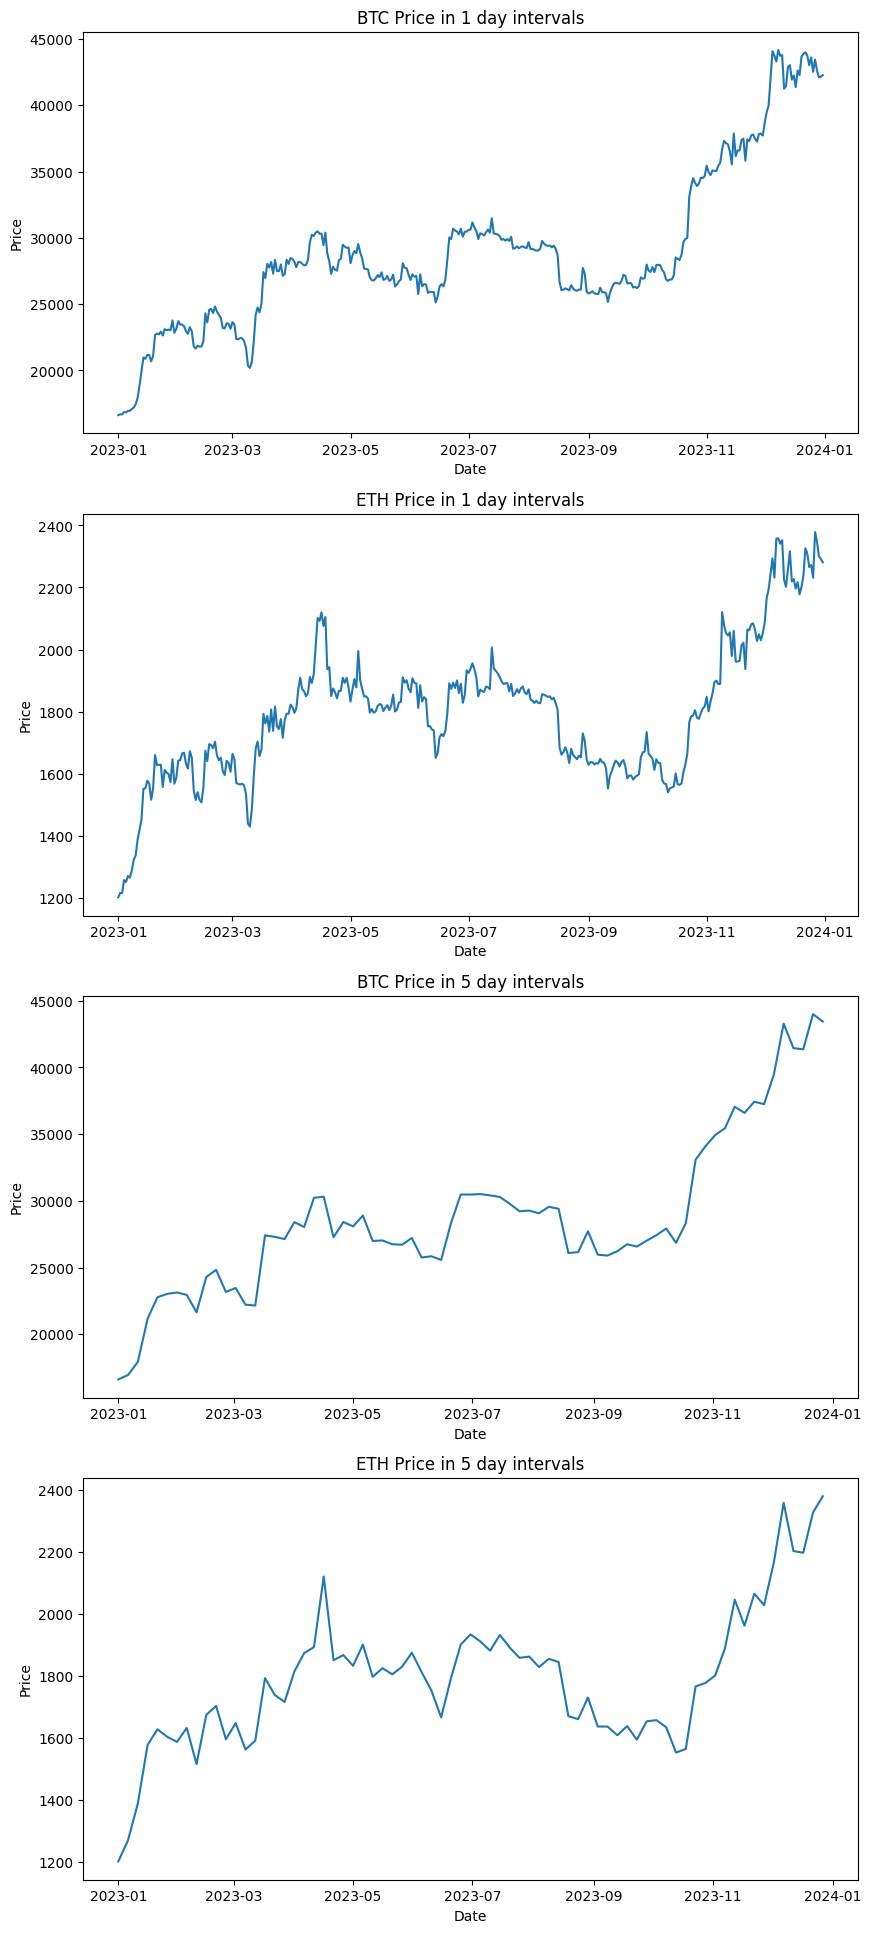

In [6]:
plt.figure(figsize=(10,24))

plt.subplot(4,1,1)
plt.plot(BTC_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 1 day intervals")

plt.subplot(4,1,2)
plt.plot(ETH_1d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 1 day intervals")

plt.subplot(4,1,3)
plt.plot(BTC_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("BTC Price in 5 day intervals")

plt.subplot(4,1,4)
plt.plot(ETH_5d.Close)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("ETH Price in 5 day intervals")

plt.show()

In [7]:
from statistics import mean, stdev

In [8]:
period = 20

In [9]:
def BollingerBand(stock):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def STD(series):
        return series.rolling(period).apply(stdev)

    def UpperBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma + std * 2

    def LowerBound(series):
        std = STD(series)
        sma = SMA(series)
        return sma - std * 2

    middle_bound = pd.Series(SMA(stock), name="middle_bound")
    upper_bound = pd.Series(UpperBound(stock), name="upper_bound")
    lower_bound = pd.Series(LowerBound(stock), name="lower_bound")
    bollinger_band = pd.concat([middle_bound, upper_bound, lower_bound], axis="columns")

    return bollinger_band

<Axes: xlabel='Date'>

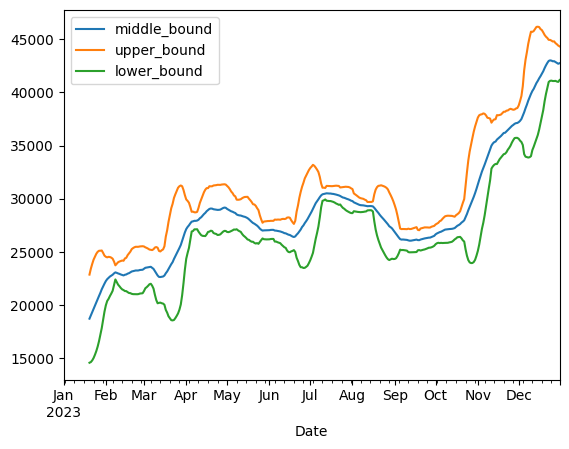

In [10]:
# This is just for test.
BollingerBand(BTC_1d.Close).plot()

In [65]:
def KeltnerChannel(stock):
    def SMA(series):
        return series.rolling(period).apply(mean)

    def return_max(series):
        return max(
            series["high_low_diff"],
            series["high_prevclose_diff"],
            series["low_prev_close_diff"],
        )

    def TR(series):
        high_low_diff = series.High - series.Low
        high_prevclose_diff = series.High - series.Close.shift(periods=1)
        low_prev_close_diff = series.Low - series.Close.shift(periods=1)
        TR = pd.concat(
            [high_low_diff, high_prevclose_diff, low_prev_close_diff],
            axis=1,
        )
        TR.columns = ["high_low_diff", "high_prevclose_diff", "low_prev_close_diff"]
        TR["TR"] = TR.apply(return_max, axis=1)
        return TR["TR"]

    return TR(stock)

<Axes: xlabel='Date'>

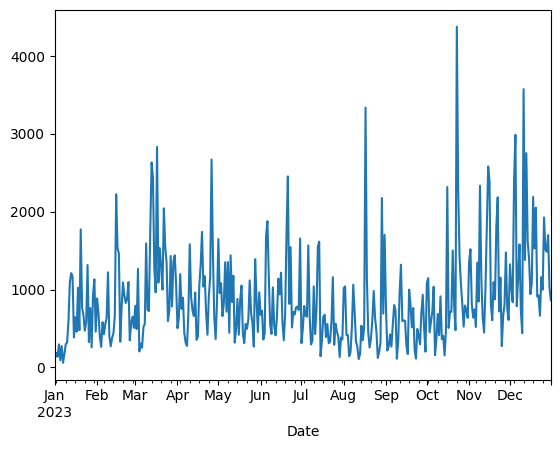

In [67]:
KeltnerChannel(BTC_1d).plot()